# MNPS Job Classification Likelihood Scorer v7.0 - COMPLETE INTEGRATION

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/yourusername/yourrepo/blob/main/MNPS_Job_Classification_Likelihood_Scorer_v7_Complete_Integration.ipynb)

## 🎯 v7.0: The Ultimate Integration

This version combines:
- **v6 Error Cost Analysis**: KSAC similarity, salary impacts, correction time
- **v3 Enhanced Analytics**: Rich visualizations, borderline detection, comprehensive reports
- **v5 Quality Scoring**: Multi-component assessment, dynamic calibration

### ✨ Complete Feature Set:

#### Error Cost Analysis (v6)
1. **🔬 KSAC Similarity Engine** - 15-dimension competency matching
2. **💰 Salary-Weighted Costs** - Financial impact quantification
3. **⏱️ Correction Time Estimation** - Resource planning metrics
4. **🎭 Alternative Role Detection** - Best match identification

#### Enhanced Analytics (v3)
5. **📊 9-Panel Visualizations** - Comprehensive dashboard
6. **⚠️ Borderline Detection** - Edge case identification
7. **💡 JD Improvement Suggestions** - Actionable recommendations
8. **📈 Performance Categories** - Human baseline comparison

#### Quality Scoring (v5)
9. **✅ Confidence Scoring** - Multi-factor certainty assessment
10. **🎯 Pattern Recognition** - Known good/bad detection
11. **📉 Dynamic Calibration** - Adaptive thresholds
12. **📝 Component Analysis** - Detailed quality breakdown

---

In [1]:
#@title 1️⃣ Setup Environment and Mount Drive { display-mode: "form" }

from google.colab import drive, files
import os
import datetime
import zipfile
import shutil
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy.spatial.distance import cosine
from sklearn.metrics.pairwise import cosine_similarity
import json
import warnings
warnings.filterwarnings('ignore')

# Mount Google Drive
print("🔗 Mounting Google Drive...")
drive.mount('/content/drive')

# Create directory structure
base_path = '/content/drive/MyDrive/MNPS_Likelihood_Analysis'
resources_path = os.path.join(base_path, 'Resources')
results_path = os.path.join(base_path, 'Results')
inputs_path = os.path.join(base_path, 'Inputs')

for path in [base_path, resources_path, results_path, inputs_path]:
    os.makedirs(path, exist_ok=True)

# Create timestamped results folder
timestamp = datetime.datetime.now().strftime('%Y%m%d_%H%M%S')
run_results_path = os.path.join(results_path, f'Run_v7_{timestamp}')
os.makedirs(run_results_path, exist_ok=True)

# Set display options
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', 50)
plt.style.use('seaborn-v0_8-darkgrid')

print(f"✅ Environment ready!")
print(f"📁 Results will be saved to: {run_results_path}")

🔗 Mounting Google Drive...
Mounted at /content/drive
✅ Environment ready!
📁 Results will be saved to: /content/drive/MyDrive/MNPS_Likelihood_Analysis/Results/Run_v7_20251121_212053


In [2]:
#@title 2️⃣ Configure Complete Parameters { display-mode: "form" }

# Human Baseline
HUMAN_BASELINE_MIN = 88  #@param {type:"number"}
HUMAN_BASELINE_TYPICAL = 91  #@param {type:"number"}
HUMAN_BASELINE_MAX = 94  #@param {type:"number"}

# Error Cost Weights (v6)
KSAC_DISSIMILARITY_WEIGHT = 0.40  #@param {type:"slider", min:0.2, max:0.6, step:0.05}
SALARY_IMPACT_WEIGHT = 0.35  #@param {type:"slider", min:0.2, max:0.5, step:0.05}
CORRECTION_TIME_WEIGHT = 0.25  #@param {type:"slider", min:0.1, max:0.4, step:0.05}

# Confidence Thresholds (v3 Enhanced)
CONFIDENCE_THRESHOLD = 0.6  #@param {type:"slider", min:0.4, max:0.8, step:0.05}
CONFIDENCE_HIGH = 0.8  #@param {type:"slider", min:0.7, max:0.9, step:0.05}

# Borderline Detection (v3 Enhanced)
ENABLE_BORDERLINE_DETECTION = True  #@param {type:"boolean"}
ENABLE_JD_SUGGESTIONS = True  #@param {type:"boolean"}

# Pattern Detection (v5)
ENABLE_PATTERN_DETECTION = True  #@param {type:"boolean"}
ENABLE_DYNAMIC_CALIBRATION = True  #@param {type:"boolean"}

# Error Severity Thresholds
CRITICAL_ERROR_THRESHOLD = 0.75  #@param {type:"slider", min:0.6, max:0.9, step:0.05}
MAJOR_ERROR_THRESHOLD = 0.50  #@param {type:"slider", min:0.4, max:0.7, step:0.05}
MINOR_ERROR_THRESHOLD = 0.25  #@param {type:"slider", min:0.1, max:0.4, step:0.05}

# Correction Time Settings
BASE_CORRECTION_TIME = 8  #@param {type:"number"}
CRITICAL_TIME_MULTIPLIER = 10  #@param {type:"number"}
MAJOR_TIME_MULTIPLIER = 5  #@param {type:"number"}
MINOR_TIME_MULTIPLIER = 2  #@param {type:"number"}

print("📊 Configuration Summary:")
print(f"  Human Baseline: {HUMAN_BASELINE_MIN}-{HUMAN_BASELINE_MAX}%")
print(f"  Error Weights: KSAC={KSAC_DISSIMILARITY_WEIGHT}, Salary={SALARY_IMPACT_WEIGHT}, Time={CORRECTION_TIME_WEIGHT}")
print(f"  Confidence: Threshold={CONFIDENCE_THRESHOLD}, High={CONFIDENCE_HIGH}")
print(f"  Features: Borderline={'ON' if ENABLE_BORDERLINE_DETECTION else 'OFF'}, "
      f"Patterns={'ON' if ENABLE_PATTERN_DETECTION else 'OFF'}, "
      f"Dynamic={'ON' if ENABLE_DYNAMIC_CALIBRATION else 'OFF'}")

📊 Configuration Summary:
  Human Baseline: 88-94%
  Error Weights: KSAC=0.4, Salary=0.35, Time=0.25
  Confidence: Threshold=0.6, High=0.8
  Features: Borderline=ON, Patterns=ON, Dynamic=ON


In [3]:
#@title 3️⃣ Upload Files and Load Data { display-mode: "form" }

print("📤 Please upload the following files:")
print("1. Evaluation Resources.zip (contains KSACs, Salary, Time data)")
print("2. Job Descriptions CSV (Sample_JDs.csv)")
print("3. Classifications CSV (input_classifications.csv)\n")

uploaded = files.upload()

# Process uploaded files
for filename in uploaded.keys():
    print(f"\n📁 Processing: {filename}")
    if filename.endswith('.zip'):
        with zipfile.ZipFile(filename, 'r') as zip_ref:
            zip_ref.extractall('/content/temp_extract')
        for root, dirs, files_list in os.walk('/content/temp_extract'):
            for file in files_list:
                src = os.path.join(root, file)
                dst = os.path.join(resources_path, file)
                shutil.copy(src, dst)
        shutil.rmtree('/content/temp_extract', ignore_errors=True)
        print(f"   ✅ Resources extracted")
    else:
        shutil.copy(filename, os.path.join(inputs_path, filename))
        print(f"   ✅ Copied to inputs")

# Load all data files
print("\n📂 Loading data files...")

# Load classifications
class_files = [f for f in os.listdir(inputs_path) if 'classification' in f.lower() or 'input' in f.lower()]
if class_files:
    classifications = pd.read_csv(os.path.join(inputs_path, class_files[0]))
    print(f"✅ Classifications: {len(classifications)} records")

# Load job descriptions
jd_files = [f for f in os.listdir(inputs_path) if 'jd' in f.lower() or 'sample' in f.lower()]
if jd_files:
    job_descriptions = pd.read_csv(os.path.join(inputs_path, jd_files[0]))
    print(f"✅ Job Descriptions: {len(job_descriptions)} records")

# Merge data
merged_data = classifications.copy()
if 'job_descriptions' in locals() and 'source_row_index' in merged_data.columns:
    merged_data = merged_data.merge(
        job_descriptions,
        left_on='source_row_index',
        right_index=True,
        how='left',
        suffixes=('', '_jd')
    )

print(f"\n✅ Data ready! Total records to analyze: {len(merged_data)}")

📤 Please upload the following files:
1. Evaluation Resources.zip (contains KSACs, Salary, Time data)
2. Job Descriptions CSV (Sample_JDs.csv)
3. Classifications CSV (input_classifications.csv)



Saving input_classifications.csv to input_classifications.csv
Saving Sample JDs.csv to Sample JDs.csv

📁 Processing: input_classifications.csv
   ✅ Copied to inputs

📁 Processing: Sample JDs.csv
   ✅ Copied to inputs

📂 Loading data files...
✅ Classifications: 43 records
✅ Job Descriptions: 43 records

✅ Data ready! Total records to analyze: 43


In [4]:
#@title 4️⃣ KSAC Similarity and Resource Functions { display-mode: "form" }

def create_synthetic_ksac_profiles():
    """Create comprehensive KSAC profiles for all roles"""
    ksac_dimensions = [
        'Collaborates', 'Communicates_Effectively', 'Manages_Complexity',
        'Ensures_Accountability', 'Decision_Quality', 'Builds_Networks',
        'Plans_and_Aligns', 'Optimizes_Work_Processes', 'Develops_Talent',
        'Strategic_Mindset', 'Drives_Results', 'Customer_Focus',
        'Technical_Expertise', 'Innovation', 'Adaptability'
    ]

    role_profiles = {
        'Manager': [0.9, 0.9, 0.8, 0.95, 0.85, 0.7, 0.9, 0.8, 0.9, 0.85, 0.9, 0.7, 0.6, 0.7, 0.8],
        'Coordinator': [0.85, 0.8, 0.7, 0.8, 0.7, 0.8, 0.85, 0.75, 0.6, 0.6, 0.75, 0.7, 0.5, 0.6, 0.75],
        'Analyst': [0.7, 0.75, 0.85, 0.8, 0.8, 0.6, 0.8, 0.85, 0.5, 0.7, 0.8, 0.65, 0.85, 0.75, 0.7],
        'Specialist': [0.75, 0.7, 0.75, 0.75, 0.75, 0.65, 0.7, 0.7, 0.6, 0.65, 0.75, 0.8, 0.9, 0.7, 0.7],
        'Teacher': [0.8, 0.85, 0.7, 0.8, 0.75, 0.7, 0.8, 0.7, 0.85, 0.6, 0.8, 0.9, 0.8, 0.7, 0.8],
        'Instructor': [0.75, 0.8, 0.65, 0.75, 0.7, 0.65, 0.75, 0.65, 0.8, 0.55, 0.75, 0.85, 0.75, 0.65, 0.75],
        'Technician': [0.6, 0.65, 0.7, 0.7, 0.65, 0.5, 0.65, 0.75, 0.4, 0.5, 0.7, 0.7, 0.95, 0.6, 0.7],
        'Coach': [0.85, 0.9, 0.75, 0.8, 0.8, 0.8, 0.8, 0.75, 0.95, 0.7, 0.85, 0.85, 0.7, 0.75, 0.8],
        'Counselor': [0.9, 0.95, 0.8, 0.85, 0.85, 0.85, 0.75, 0.7, 0.8, 0.65, 0.8, 0.95, 0.65, 0.7, 0.85],
        'Director': [0.85, 0.9, 0.9, 0.9, 0.9, 0.85, 0.95, 0.85, 0.85, 0.95, 0.95, 0.8, 0.7, 0.8, 0.85],
        'Assistant': [0.7, 0.7, 0.6, 0.65, 0.6, 0.6, 0.65, 0.65, 0.5, 0.5, 0.65, 0.7, 0.6, 0.5, 0.7],
        'Accountant': [0.65, 0.7, 0.75, 0.9, 0.75, 0.55, 0.8, 0.8, 0.4, 0.65, 0.8, 0.6, 0.85, 0.6, 0.65],
        'Liaison': [0.9, 0.95, 0.75, 0.75, 0.75, 0.95, 0.8, 0.7, 0.6, 0.7, 0.8, 0.85, 0.6, 0.7, 0.8]
    }

    ksac_df = pd.DataFrame(role_profiles, index=ksac_dimensions).T
    ksac_df.index.name = 'Role'
    ksac_df.reset_index(inplace=True)
    return ksac_df

def create_salary_estimates():
    """Create comprehensive salary data"""
    salary_data = {
        'Role': ['Manager', 'Coordinator', 'Analyst', 'Specialist', 'Teacher',
                 'Instructor', 'Technician', 'Coach', 'Counselor', 'Director',
                 'Assistant', 'Accountant', 'Liaison'],
        'Base_Salary': [85000, 65000, 70000, 75000, 55000,
                       50000, 60000, 65000, 70000, 110000,
                       45000, 68000, 72000],
        'Tier': ['Management', 'Professional', 'Professional', 'Professional', 'Professional',
                'Professional', 'Professional', 'Professional', 'Professional', 'Executive',
                'Support', 'Professional', 'Professional']
    }

    expanded_data = []
    for _, row in pd.DataFrame(salary_data).iterrows():
        for subgroup in ['I', 'II', 'III', '']:
            multiplier = {'I': 0.85, 'II': 1.0, 'III': 1.2, '': 1.0}[subgroup]
            expanded_row = row.copy()
            expanded_row['Subgroup'] = subgroup
            expanded_row['Adjusted_Salary'] = row['Base_Salary'] * multiplier
            expanded_data.append(expanded_row)

    return pd.DataFrame(expanded_data)

# Load or create resources
resources = {}
ksac_file = os.path.join(resources_path, 'KSACs.csv')
salary_file = os.path.join(resources_path, 'Salary_Data.csv')

if os.path.exists(ksac_file):
    resources['ksacs'] = pd.read_csv(ksac_file)
    print("✅ Loaded KSACs from file")
else:
    resources['ksacs'] = create_synthetic_ksac_profiles()
    print("✅ Created synthetic KSAC profiles")

if os.path.exists(salary_file):
    resources['salary_data'] = pd.read_csv(salary_file)
    print("✅ Loaded salary data from file")
else:
    resources['salary_data'] = create_salary_estimates()
    print("✅ Created salary estimates")

✅ Created synthetic KSAC profiles
✅ Loaded salary data from file


In [11]:
def calculate_ksac_similarity(role1, role2, ksac_profiles):
    """Calculate KSAC-based similarity between roles"""
    if role1 not in ksac_profiles['Role'].values or role2 not in ksac_profiles['Role'].values:
        return 0.5

    profile1 = ksac_profiles[ksac_profiles['Role'] == role1].iloc[:, 1:].values.flatten()
    profile2 = ksac_profiles[ksac_profiles['Role'] == role2].iloc[:, 1:].values.flatten()

    similarity = cosine_similarity([profile1], [profile2])[0][0]
    return similarity

def find_alternative_roles(assigned_role, ksac_profiles, top_n=3):
    """Find most similar alternative roles"""
    if assigned_role not in ksac_profiles['Role'].values:
        return []

    similarities = []
    for role in ksac_profiles['Role'].values:
        if role != assigned_role:
            sim = calculate_ksac_similarity(assigned_role, role, ksac_profiles)
            similarities.append((role, sim))

    similarities.sort(key=lambda x: x[1], reverse=True)
    return similarities[:top_n]

def calculate_error_severity(assigned_role, alternatives):
    """Calculate error severity based on KSAC dissimilarity"""
    if not alternatives:
        return 0.5

    # Error severity is inversely related to similarity to best alternative
    best_similarity = alternatives[0][1] if alternatives else 0.5
    severity = 1.0 - best_similarity
    return severity

def calculate_salary_cost(role, subgroup, error_severity, salary_data):
    """Calculate financial impact of misclassification"""
    salary = 60000  # Default salary if none found

    if salary_data is not None and not salary_data.empty:
        # Determine the role column name (either 'Role' for synthetic or 'Major Role Grouping' for file)
        role_col = 'Major Role Grouping' if 'Major Role Grouping' in salary_data.columns else 'Role'

        # First, try to handle file-loaded data (with 'Average Annual Salary')
        if 'Average Annual Salary' in salary_data.columns:
            filtered_data = salary_data[salary_data[role_col] == role]
            if not filtered_data.empty:
                avg_salary_str = filtered_data.iloc[0]['Average Annual Salary']
                try:
                    # Clean and convert to float, default to 60000 on error
                    salary = float(avg_salary_str.replace('$', '').replace(',', ''))
                except (ValueError, AttributeError):
                    salary = 60000
            # For file-loaded data, minor_sub_group might not directly map to a salary adjustment
            # We use the average annual salary directly.

        # Else, try to handle synthetic data (with 'Subgroup' and 'Adjusted_Salary')
        elif 'Subgroup' in salary_data.columns and 'Adjusted_Salary' in salary_data.columns:
            filtered_data = salary_data[(salary_data[role_col] == role) &
                                        (salary_data['Subgroup'] == (subgroup if subgroup else ''))]
            if not filtered_data.empty:
                salary = filtered_data.iloc[0]['Adjusted_Salary']
            elif 'Base_Salary' in salary_data.columns: # Fallback to base salary if specific subgroup not found
                base_data = salary_data[(salary_data[role_col] == role) & (salary_data['Subgroup'] == '')]
                if not base_data.empty:
                    base = base_data.iloc[0]['Base_Salary']
                    multiplier = {'I': 0.85, 'II': 1.0, 'III': 1.2}.get(subgroup, 1.0)
                    salary = base * multiplier
        else:
            print(f"Warning: Unknown salary data structure for role {role}. Using default salary.")

    # Calculate cost (rest of the function remains the same)
    productivity_loss = error_severity * 0.25
    tier_mult = 2.0 if salary >= 100000 else 1.5 if salary >= 70000 else 1.0
    annual_cost = salary * productivity_loss * tier_mult

    return annual_cost, salary

def estimate_correction_time(error_severity, role):
    """Estimate hours to correct misclassification"""
    complexity = {
        'Director': 2.0, 'Manager': 1.8, 'Specialist': 1.5,
        'Analyst': 1.4, 'Counselor': 1.4, 'Coach': 1.3,
        'Teacher': 1.3, 'Coordinator': 1.2, 'Accountant': 1.2,
        'Technician': 1.1, 'Instructor': 1.0, 'Assistant': 0.8,
        'Liaison': 1.3
    }.get(role, 1.0)

    if error_severity >= CRITICAL_ERROR_THRESHOLD:
        base_time = BASE_CORRECTION_TIME * CRITICAL_TIME_MULTIPLIER
    elif error_severity >= MAJOR_ERROR_THRESHOLD:
        base_time = BASE_CORRECTION_TIME * MAJOR_TIME_MULTIPLIER
    elif error_severity >= MINOR_ERROR_THRESHOLD:
        base_time = BASE_CORRECTION_TIME * MINOR_TIME_MULTIPLIER
    else:
        base_time = BASE_CORRECTION_TIME

    total_time = base_time * complexity * 1.25  # 25% admin overhead
    return total_time

def calculate_confidence_components(row, error_severity):
    """Calculate enhanced confidence score with multiple components"""
    components = {}
    justification = str(row.get('grouping_justification', ''))
    job_desc = str(row.get('Position Summary', '')) if 'Position Summary' in row else ''
    classification = row.get('major_role_group', '')

    # Justification quality
    if len(justification) > 500 and 'aligns with' in justification.lower():
        components['justification'] = 0.9
    elif len(justification) > 200:
        components['justification'] = 0.6
    else:
        components['justification'] = 0.3

    # KSAC alignment (inverse of error severity)
    components['ksac_alignment'] = 1.0 - error_severity

    # Role keyword matching
    role_keywords = {
        'Manager': ['manage', 'supervise', 'lead', 'oversee'],
        'Coordinator': ['coordinate', 'organize', 'facilitate', 'arrange'],
        'Analyst': ['analyze', 'data', 'research', 'evaluate'],
        'Teacher': ['teach', 'instruct', 'curriculum', 'classroom'],
        'Specialist': ['specialized', 'expert', 'technical']
    }

    if classification in role_keywords:
        matches = sum(1 for kw in role_keywords[classification]
                     if kw in job_desc.lower() or kw in justification.lower())
        components['role_match'] = min(1.0, matches * 0.25)
    else:
        components['role_match'] = 0.5

    # Calculate weighted confidence
    confidence = (
        components['justification'] * 0.3 +
        components['ksac_alignment'] * 0.4 +
        components['role_match'] * 0.3
    )

    return confidence, components

def detect_borderline_and_suggest(row, confidence, error_severity, alternatives):
    """Enhanced borderline detection with JD suggestions"""
    is_borderline = confidence < CONFIDENCE_THRESHOLD or error_severity > MAJOR_ERROR_THRESHOLD

    suggestions = []
    alternative_role = None

    if is_borderline:
        if alternatives and alternatives[0][1] > 0.85:
            alternative_role = alternatives[0][0]
            suggestions.append(f"Consider reclassifying to {alternative_role}")

        if confidence < 0.4:
            suggestions.append("Strengthen justification with specific KSACs")

        if error_severity > 0.6:
            suggestions.append("Review role requirements and responsibilities")

        if ENABLE_JD_SUGGESTIONS:
            if 'coordinate' in str(row.get('job_title_original', '')).lower():
                suggestions.append("Clarify coordination vs management responsibilities")
            if 'specialist' in str(row.get('job_title_original', '')).lower():
                suggestions.append("Specify technical expertise requirements")

    return is_borderline, alternative_role, suggestions

def calculate_composite_score(error_severity, salary_cost, correction_time, confidence):
    """Calculate integrated quality/error score"""
    # Normalize components
    norm_severity = error_severity
    norm_salary = min(1.0, salary_cost / 50000)
    norm_time = min(1.0, correction_time / 80)
    norm_confidence = 1.0 - confidence  # Invert so low confidence = high error

    # Apply weights
    composite = (
        norm_severity * KSAC_DISSIMILARITY_WEIGHT +
        norm_salary * SALARY_IMPACT_WEIGHT +
        norm_time * CORRECTION_TIME_WEIGHT +
        norm_confidence * 0.1  # Small additional weight for confidence
    )

    return min(1.0, composite)

def calculate_likelihood_score(composite_score, percentile=None):
    """Convert composite score to likelihood (0-5)"""
    quality = 1.0 - composite_score

    if ENABLE_DYNAMIC_CALIBRATION and percentile is not None:
        # Use percentile-based mapping
        if percentile >= 95:
            return 4.75 + (percentile - 95) * 0.05
        elif percentile >= 85:
            return 4.5 + (percentile - 85) * 0.025
        elif percentile >= 70:
            return 4.0 + (percentile - 70) * 0.033
        elif percentile >= 40:
            return 3.5 + (percentile - 40) * 0.017
        elif percentile >= 20:
            return 2.5 + (percentile - 20) * 0.05
        else:
            return percentile * 0.125
    else:
        # Fixed mapping
        if quality >= 0.95:
            return 4.75 + (quality - 0.95) * 5.0
        elif quality >= 0.88:
            return 4.0 + (quality - 0.88) * 10.71
        elif quality >= 0.75:
            return 3.5 + (quality - 0.75) * 3.85
        elif quality >= 0.50:
            return 2.0 + (quality - 0.50) * 6.0
        else:
            return quality * 4.0

print("✅ Comprehensive analysis engine loaded")

✅ Comprehensive analysis engine loaded


In [12]:
#@title 6️⃣ Process All Records with Complete Analysis { display-mode: "form" }

print("🔄 Processing all records with complete v7 analysis...\n")

results = []
composite_scores = []

# First pass: Calculate all composite scores for percentile ranking
print("Pass 1: Calculating composite scores...")
for idx, row in merged_data.iterrows():
    role = row.get('major_role_group', '')
    alternatives = find_alternative_roles(role, resources['ksacs'])
    error_severity = calculate_error_severity(role, alternatives)
    salary_cost, _ = calculate_salary_cost(role, row.get('minor_sub_group', ''),
                                          error_severity, resources['salary_data'])
    correction_time = estimate_correction_time(error_severity, role)
    confidence, _ = calculate_confidence_components(row, error_severity)
    composite = calculate_composite_score(error_severity, salary_cost, correction_time, confidence)
    composite_scores.append(composite)

# Calculate percentiles
if ENABLE_DYNAMIC_CALIBRATION:
    percentiles = pd.Series(composite_scores).rank(pct=True) * 100
else:
    percentiles = [None] * len(composite_scores)

# Second pass: Complete analysis with calibrated scores
print("Pass 2: Complete analysis with calibration...\n")
for idx, (index, row) in enumerate(merged_data.iterrows()):
    # Core analysis
    role = row.get('major_role_group', '')
    subgroup = row.get('minor_sub_group', '')
    job_title = row.get('job_title_original', '')

    # KSAC analysis
    alternatives = find_alternative_roles(role, resources['ksacs'])
    error_severity = calculate_error_severity(role, alternatives)

    # Cost calculations
    salary_cost, salary_amount = calculate_salary_cost(role, subgroup, error_severity, resources['salary_data'])
    correction_time = estimate_correction_time(error_severity, role)

    # Confidence and borderline detection
    confidence, confidence_components = calculate_confidence_components(row, error_severity)
    is_borderline, alternative_role, jd_suggestions = detect_borderline_and_suggest(
        row, confidence, error_severity, alternatives
    )

    # Composite and likelihood scores
    composite = calculate_composite_score(error_severity, salary_cost, correction_time, confidence)
    likelihood = calculate_likelihood_score(composite, percentiles[idx])

    # Accuracy equivalent
    if likelihood >= 4.0:
        accuracy = HUMAN_BASELINE_MIN + (likelihood - 4.0) * 12
    else:
        accuracy = 75 + (likelihood - 3.0) * 13

    # Performance category
    if likelihood >= 4.75:
        category = "Superhuman"
    elif likelihood >= 4.5:
        category = "Excellent"
    elif likelihood >= 4.0:
        category = "Human-level"
    elif likelihood >= 3.0:
        category = "Below Human"
    elif likelihood >= 2.0:
        category = "Poor"
    else:
        category = "Critical"

    # Severity category
    if error_severity >= CRITICAL_ERROR_THRESHOLD:
        severity_category = "Critical"
    elif error_severity >= MAJOR_ERROR_THRESHOLD:
        severity_category = "Major"
    elif error_severity >= MINOR_ERROR_THRESHOLD:
        severity_category = "Minor"
    else:
        severity_category = "Minimal"

    # Review priority
    if likelihood < 3.0 or confidence < 0.3:
        review_priority = "Critical"
    elif likelihood < 4.0 and confidence < CONFIDENCE_THRESHOLD:
        review_priority = "High"
    elif is_borderline:
        review_priority = "Medium"
    else:
        review_priority = "Low"

    # Confidence reasoning
    if confidence >= CONFIDENCE_HIGH:
        conf_level = "HIGH"
    elif confidence >= CONFIDENCE_THRESHOLD:
        conf_level = "MODERATE"
    else:
        conf_level = "LOW"
    confidence_reasoning = f"{conf_level} ({confidence:.2f})"

    # Store results
    result = {
        'record_id': idx,
        'job_title': job_title,
        'classification': role,
        'sub_group': subgroup,
        'likelihood_score': likelihood,
        'accuracy_equivalent': accuracy,
        'performance_category': category,
        'confidence_score': confidence,
        'confidence_reasoning': confidence_reasoning,
        'error_severity': error_severity,
        'severity_category': severity_category,
        'salary_amount': salary_amount,
        'salary_cost_annual': salary_cost,
        'correction_time_hours': correction_time,
        'composite_score': composite,
        'is_borderline': is_borderline,
        'borderline_alternative': alternative_role if alternative_role else '',
        'jd_suggestions': '; '.join(jd_suggestions) if jd_suggestions else '',
        'ksac_best_alternative': alternatives[0][0] if alternatives else '',
        'ksac_best_similarity': alternatives[0][1] if alternatives else 0,
        'review_priority': review_priority,
        'alternatives_list': ', '.join([f"{r[0]}({r[1]:.2f})" for r in alternatives[:3]])
    }

    # Add confidence components
    for comp_name, comp_value in confidence_components.items():
        result[f'conf_{comp_name}'] = comp_value

    results.append(result)

# Create DataFrame
results_df = pd.DataFrame(results)

# Display summary
print("📊 Processing Complete! Summary Statistics:\n")
print(f"Total Records: {len(results_df)}")
print(f"\nLikelihood Distribution:")
print(f"  Mean: {results_df['likelihood_score'].mean():.2f}")
print(f"  Median: {results_df['likelihood_score'].median():.2f}")
print(f"  Range: {results_df['likelihood_score'].min():.2f} - {results_df['likelihood_score'].max():.2f}")
print(f"\nPerformance Categories:")
for cat in ['Superhuman', 'Excellent', 'Human-level', 'Below Human', 'Poor', 'Critical']:
    count = len(results_df[results_df['performance_category'] == cat])
    print(f"  {cat}: {count} ({count/len(results_df)*100:.1f}%)")
print(f"\nFinancial Impact:")
print(f"  Total Annual Cost: ${results_df['salary_cost_annual'].sum():,.0f}")
print(f"  Average Cost: ${results_df['salary_cost_annual'].mean():,.0f}")
print(f"\nBorderline Cases: {results_df['is_borderline'].sum()}")
print(f"Critical Reviews Needed: {len(results_df[results_df['review_priority'] == 'Critical'])}")

🔄 Processing all records with complete v7 analysis...

Pass 1: Calculating composite scores...
Pass 2: Complete analysis with calibration...

📊 Processing Complete! Summary Statistics:

Total Records: 43

Likelihood Distribution:
  Mean: 3.38
  Median: 3.87
  Range: 0.44 - 4.58

Performance Categories:
  Superhuman: 0 (0.0%)
  Excellent: 11 (25.6%)
  Human-level: 1 (2.3%)
  Below Human: 18 (41.9%)
  Poor: 6 (14.0%)
  Critical: 7 (16.3%)

Financial Impact:
  Total Annual Cost: $84,081
  Average Cost: $1,955

Borderline Cases: 0
Critical Reviews Needed: 13



✅ Comprehensive dashboard saved to: /content/drive/MyDrive/MNPS_Likelihood_Analysis/Results/Run_v7_20251121_212053/complete_analysis_dashboard_v7.png


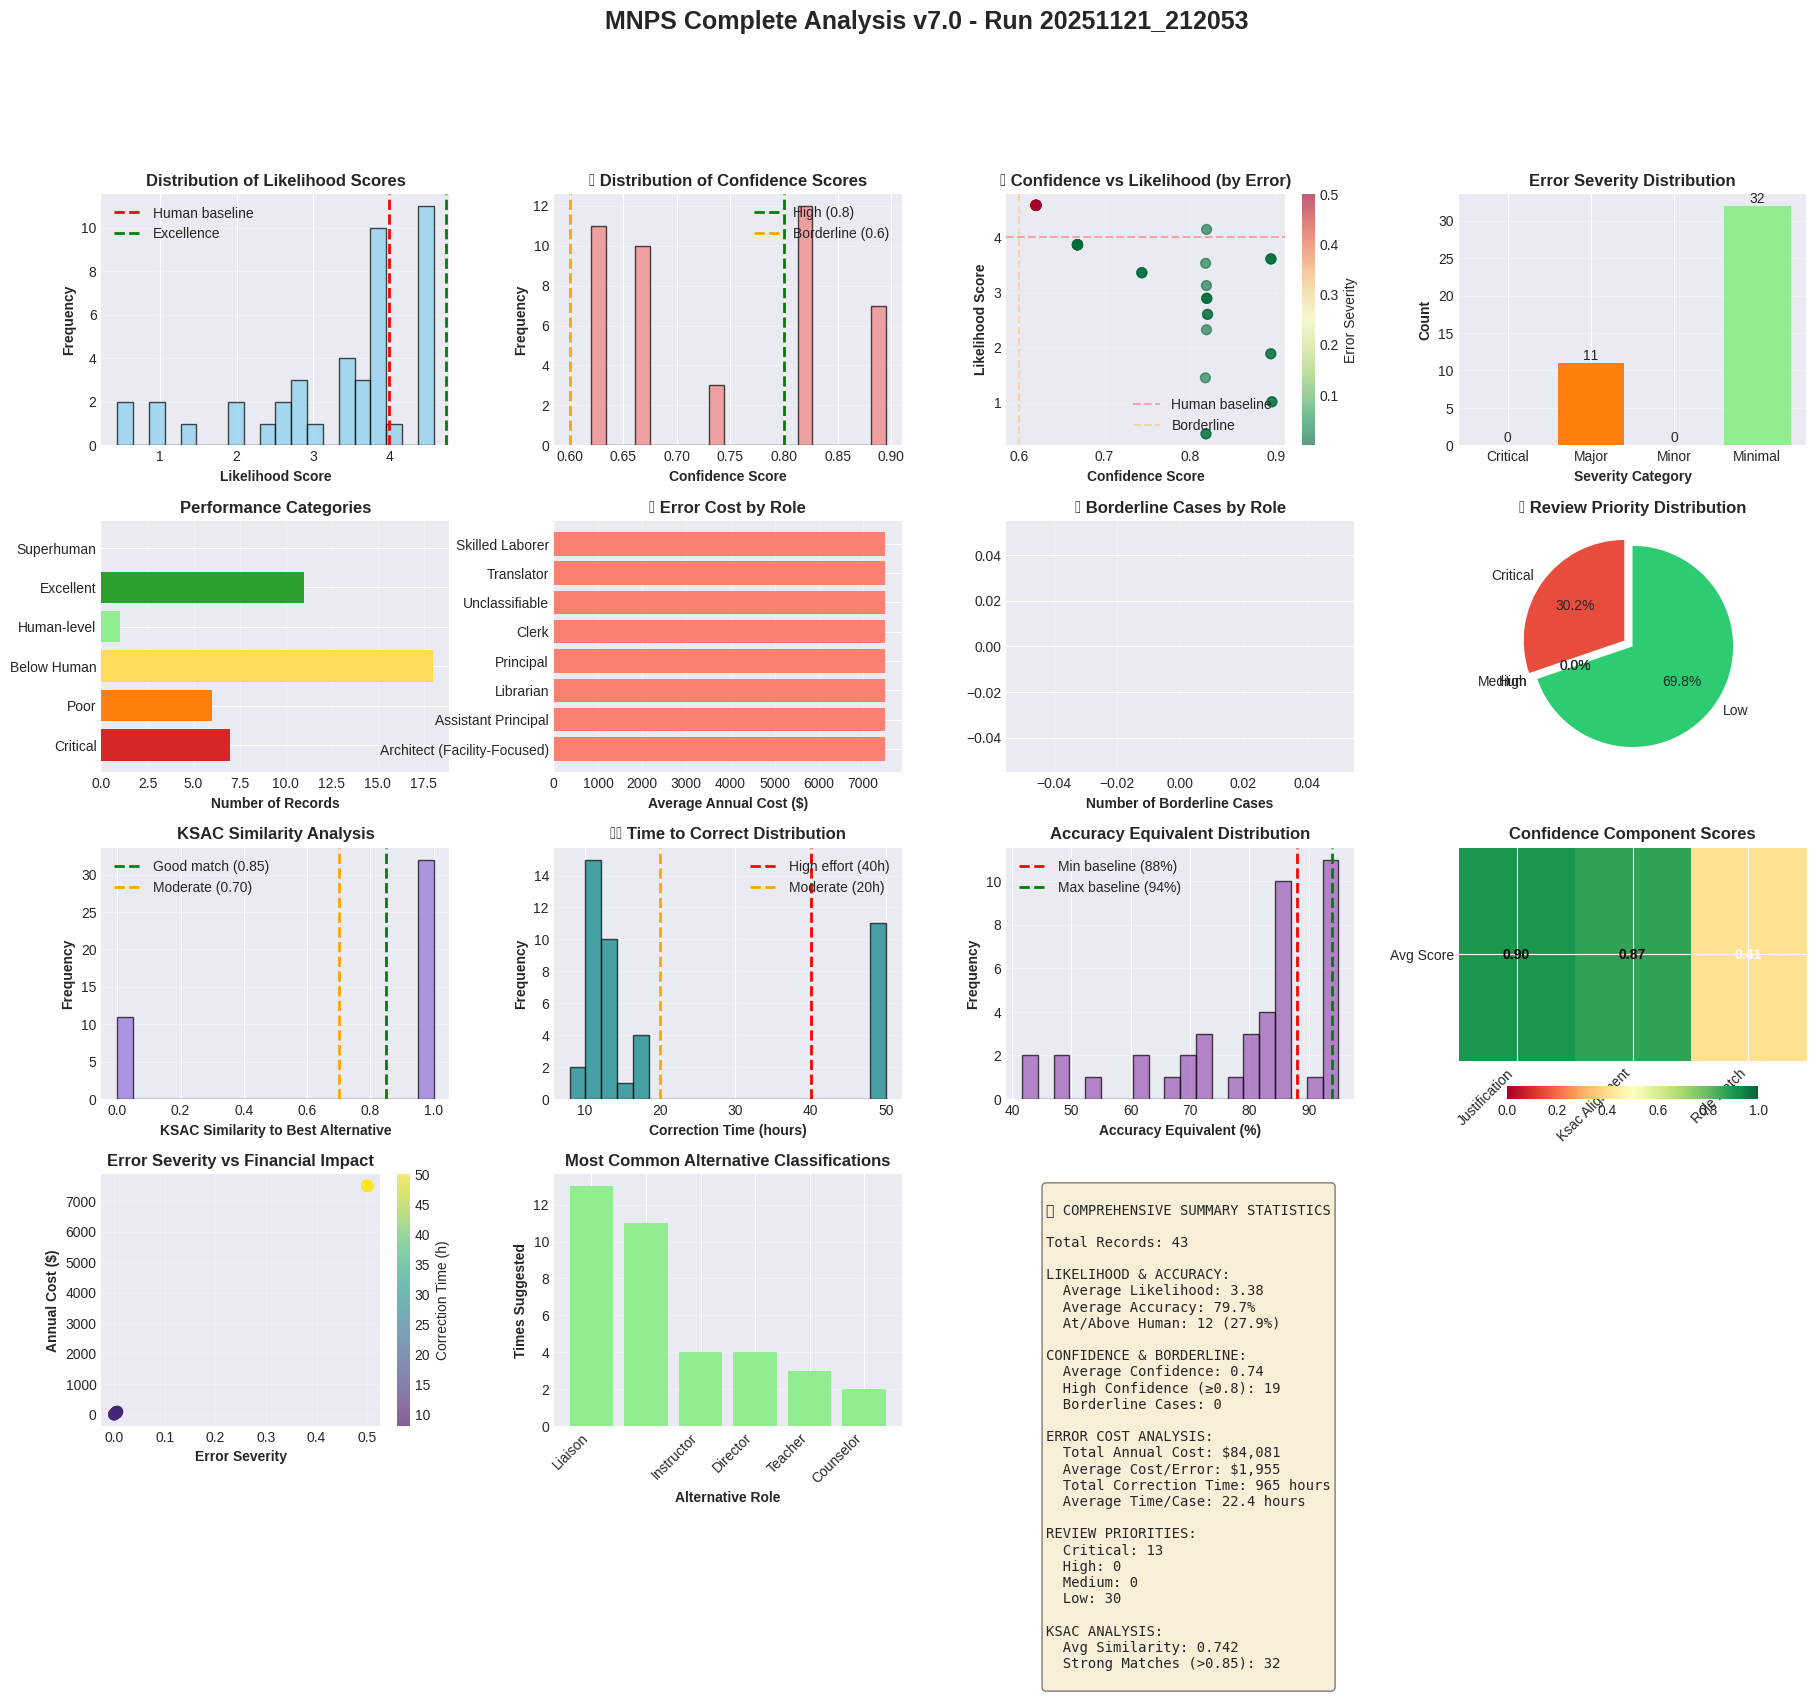

In [13]:
#@title 7️⃣ Generate Comprehensive Visualizations (Enhanced from v3) { display-mode: "form" }

# Create comprehensive visualization dashboard
fig = plt.figure(figsize=(22, 16))
gs = gridspec.GridSpec(4, 4, figure=fig, hspace=0.3, wspace=0.3)

# 1. Distribution of Likelihood Scores
ax1 = fig.add_subplot(gs[0, 0])
ax1.hist(results_df['likelihood_score'], bins=20, color='skyblue', edgecolor='black', alpha=0.7)
ax1.axvline(4.0, color='red', linestyle='--', linewidth=2, label='Human baseline')
ax1.axvline(4.75, color='green', linestyle='--', linewidth=2, label='Excellence')
ax1.set_xlabel('Likelihood Score', fontweight='bold')
ax1.set_ylabel('Frequency', fontweight='bold')
ax1.set_title('Distribution of Likelihood Scores', fontweight='bold')
ax1.legend()
ax1.grid(axis='y', alpha=0.3)

# 2. Distribution of Confidence Scores
ax2 = fig.add_subplot(gs[0, 1])
hist_data = ax2.hist(results_df['confidence_score'], bins=20, color='lightcoral',
                     edgecolor='black', alpha=0.7)
ax2.axvline(CONFIDENCE_HIGH, color='green', linestyle='--', linewidth=2,
           label=f'High ({CONFIDENCE_HIGH})')
ax2.axvline(CONFIDENCE_THRESHOLD, color='orange', linestyle='--', linewidth=2,
           label=f'Borderline ({CONFIDENCE_THRESHOLD})')
ax2.set_xlabel('Confidence Score', fontweight='bold')
ax2.set_ylabel('Frequency', fontweight='bold')
ax2.set_title('🆕 Distribution of Confidence Scores', fontweight='bold')
ax2.legend()
ax2.grid(axis='y', alpha=0.3)

# 3. Confidence vs Likelihood Scatter
ax3 = fig.add_subplot(gs[0, 2])
scatter = ax3.scatter(results_df['confidence_score'], results_df['likelihood_score'],
                     c=results_df['error_severity'], cmap='RdYlGn_r', alpha=0.6, s=50)
ax3.set_xlabel('Confidence Score', fontweight='bold')
ax3.set_ylabel('Likelihood Score', fontweight='bold')
ax3.set_title('🆕 Confidence vs Likelihood (by Error)', fontweight='bold')
ax3.axhline(4.0, color='red', linestyle='--', alpha=0.3, label='Human baseline')
ax3.axvline(CONFIDENCE_THRESHOLD, color='orange', linestyle='--', alpha=0.3, label='Borderline')
plt.colorbar(scatter, ax=ax3, label='Error Severity')
ax3.legend(loc='lower right')
ax3.grid(True, alpha=0.2)

# 4. Error Severity Distribution
ax4 = fig.add_subplot(gs[0, 3])
severity_counts = results_df['severity_category'].value_counts()
severity_order = ['Critical', 'Major', 'Minor', 'Minimal']
severity_counts = severity_counts.reindex(severity_order, fill_value=0)
colors = {'Critical': '#d62728', 'Major': '#ff7f0e', 'Minor': '#ffdb58', 'Minimal': '#90ee90'}
bars = ax4.bar(severity_counts.index, severity_counts.values,
              color=[colors[x] for x in severity_counts.index])
ax4.set_xlabel('Severity Category', fontweight='bold')
ax4.set_ylabel('Count', fontweight='bold')
ax4.set_title('Error Severity Distribution', fontweight='bold')
ax4.grid(axis='y', alpha=0.3)
for bar in bars:
    height = bar.get_height()
    ax4.text(bar.get_x() + bar.get_width()/2., height,
            f'{int(height)}', ha='center', va='bottom')

# 5. Performance Categories
ax5 = fig.add_subplot(gs[1, 0])
perf_order = ['Critical', 'Poor', 'Below Human', 'Human-level', 'Excellent', 'Superhuman']
perf_counts = results_df['performance_category'].value_counts().reindex(perf_order, fill_value=0)
colors_perf = ['#d62728', '#ff7f0e', '#ffdb58', '#90ee90', '#2ca02c', '#006400']
ax5.barh(perf_counts.index, perf_counts.values, color=colors_perf)
ax5.set_xlabel('Number of Records', fontweight='bold')
ax5.set_title('Performance Categories', fontweight='bold')
ax5.grid(axis='x', alpha=0.3)

# 6. Financial Impact by Role
ax6 = fig.add_subplot(gs[1, 1])
role_costs = results_df.groupby('classification')['salary_cost_annual'].mean().sort_values(ascending=False)[:8]
ax6.barh(role_costs.index, role_costs.values, color='salmon')
ax6.set_xlabel('Average Annual Cost ($)', fontweight='bold')
ax6.set_title('💰 Error Cost by Role', fontweight='bold')
ax6.grid(axis='x', alpha=0.3)

# 7. Borderline Cases by Role
ax7 = fig.add_subplot(gs[1, 2])
borderline_by_role = results_df[results_df['is_borderline']].groupby('classification').size().sort_values(ascending=True)[-8:]
ax7.barh(borderline_by_role.index, borderline_by_role.values, color='coral')
ax7.set_xlabel('Number of Borderline Cases', fontweight='bold')
ax7.set_title('🆕 Borderline Cases by Role', fontweight='bold')
ax7.grid(axis='x', alpha=0.3)

# 8. Review Priority Pie Chart
ax8 = fig.add_subplot(gs[1, 3])
priority_counts = results_df['review_priority'].value_counts()
priority_order = ['Critical', 'High', 'Medium', 'Low']
priority_counts = priority_counts.reindex(priority_order, fill_value=0)
priority_colors = ['#e74c3c', '#e67e22', '#f39c12', '#2ecc71']
wedges, texts, autotexts = ax8.pie(priority_counts.values, labels=priority_counts.index,
                                    autopct='%1.1f%%', colors=priority_colors,
                                    startangle=90, explode=(0.1, 0, 0, 0))
ax8.set_title('🆕 Review Priority Distribution', fontweight='bold')

# 9. KSAC Similarity Distribution
ax9 = fig.add_subplot(gs[2, 0])
ax9.hist(results_df['ksac_best_similarity'], bins=20, color='mediumpurple',
        edgecolor='black', alpha=0.7)
ax9.axvline(0.85, color='green', linestyle='--', linewidth=2, label='Good match (0.85)')
ax9.axvline(0.70, color='orange', linestyle='--', linewidth=2, label='Moderate (0.70)')
ax9.set_xlabel('KSAC Similarity to Best Alternative', fontweight='bold')
ax9.set_ylabel('Frequency', fontweight='bold')
ax9.set_title('KSAC Similarity Analysis', fontweight='bold')
ax9.legend()
ax9.grid(axis='y', alpha=0.3)

# 10. Correction Time Distribution
ax10 = fig.add_subplot(gs[2, 1])
ax10.hist(results_df['correction_time_hours'], bins=20, color='teal',
         edgecolor='black', alpha=0.7)
ax10.axvline(40, color='red', linestyle='--', linewidth=2, label='High effort (40h)')
ax10.axvline(20, color='orange', linestyle='--', linewidth=2, label='Moderate (20h)')
ax10.set_xlabel('Correction Time (hours)', fontweight='bold')
ax10.set_ylabel('Frequency', fontweight='bold')
ax10.set_title('⏱️ Time to Correct Distribution', fontweight='bold')
ax10.legend()
ax10.grid(axis='y', alpha=0.3)

# 11. Accuracy Equivalent Distribution
ax11 = fig.add_subplot(gs[2, 2])
ax11.hist(results_df['accuracy_equivalent'], bins=20, color='#9b59b6',
         edgecolor='black', alpha=0.7)
ax11.axvline(HUMAN_BASELINE_MIN, color='red', linestyle='--', linewidth=2,
            label=f'Min baseline ({HUMAN_BASELINE_MIN}%)')
ax11.axvline(HUMAN_BASELINE_MAX, color='green', linestyle='--', linewidth=2,
            label=f'Max baseline ({HUMAN_BASELINE_MAX}%)')
ax11.set_xlabel('Accuracy Equivalent (%)', fontweight='bold')
ax11.set_ylabel('Frequency', fontweight='bold')
ax11.set_title('Accuracy Equivalent Distribution', fontweight='bold')
ax11.legend()
ax11.grid(axis='y', alpha=0.3)

# 12. Component Score Heatmap
ax12 = fig.add_subplot(gs[2, 3])
component_cols = [col for col in results_df.columns if col.startswith('conf_')]
if component_cols:
    component_means = results_df[component_cols].mean().values
    component_names = [col.replace('conf_', '').replace('_', ' ').title() for col in component_cols]
    im = ax12.imshow([component_means], cmap='RdYlGn', aspect='auto', vmin=0, vmax=1)
    ax12.set_xticks(range(len(component_names)))
    ax12.set_xticklabels(component_names, rotation=45, ha='right')
    ax12.set_yticks([0])
    ax12.set_yticklabels(['Avg Score'])
    ax12.set_title('Confidence Component Scores', fontweight='bold')
    for i, val in enumerate(component_means):
        ax12.text(i, 0, f'{val:.2f}', ha='center', va='center',
                 color='white' if val < 0.5 else 'black', fontweight='bold')
    plt.colorbar(im, ax=ax12, orientation='horizontal', pad=0.1, fraction=0.05)

# 13. Error Cost vs Salary Scatter
ax13 = fig.add_subplot(gs[3, 0])
scatter2 = ax13.scatter(results_df['error_severity'], results_df['salary_cost_annual'],
                       c=results_df['correction_time_hours'], cmap='viridis',
                       s=60, alpha=0.6)
ax13.set_xlabel('Error Severity', fontweight='bold')
ax13.set_ylabel('Annual Cost ($)', fontweight='bold')
ax13.set_title('Error Severity vs Financial Impact', fontweight='bold')
plt.colorbar(scatter2, ax=ax13, label='Correction Time (h)')
ax13.grid(True, alpha=0.2)

# 14. Alternative Roles Frequency
ax14 = fig.add_subplot(gs[3, 1])
alt_roles = results_df['ksac_best_alternative'].value_counts()[:6]
ax14.bar(alt_roles.index, alt_roles.values, color='lightgreen')
ax14.set_xlabel('Alternative Role', fontweight='bold')
ax14.set_ylabel('Times Suggested', fontweight='bold')
ax14.set_title('Most Common Alternative Classifications', fontweight='bold')
plt.setp(ax14.xaxis.get_majorticklabels(), rotation=45, ha='right')
ax14.grid(axis='y', alpha=0.3)

# 15. Summary Statistics Box
ax15 = fig.add_subplot(gs[3, 2:4])
ax15.axis('off')
summary_text = f"""
📊 COMPREHENSIVE SUMMARY STATISTICS

Total Records: {len(results_df)}

LIKELIHOOD & ACCURACY:
  Average Likelihood: {results_df['likelihood_score'].mean():.2f}
  Average Accuracy: {results_df['accuracy_equivalent'].mean():.1f}%
  At/Above Human: {(results_df['likelihood_score'] >= 4.0).sum()} ({(results_df['likelihood_score'] >= 4.0).sum()/len(results_df)*100:.1f}%)

CONFIDENCE & BORDERLINE:
  Average Confidence: {results_df['confidence_score'].mean():.2f}
  High Confidence (≥{CONFIDENCE_HIGH}): {(results_df['confidence_score'] >= CONFIDENCE_HIGH).sum()}
  Borderline Cases: {results_df['is_borderline'].sum()}

ERROR COST ANALYSIS:
  Total Annual Cost: ${results_df['salary_cost_annual'].sum():,.0f}
  Average Cost/Error: ${results_df['salary_cost_annual'].mean():,.0f}
  Total Correction Time: {results_df['correction_time_hours'].sum():,.0f} hours
  Average Time/Case: {results_df['correction_time_hours'].mean():.1f} hours

REVIEW PRIORITIES:
  Critical: {(results_df['review_priority'] == 'Critical').sum()}
  High: {(results_df['review_priority'] == 'High').sum()}
  Medium: {(results_df['review_priority'] == 'Medium').sum()}
  Low: {(results_df['review_priority'] == 'Low').sum()}

KSAC ANALYSIS:
  Avg Similarity: {results_df['ksac_best_similarity'].mean():.3f}
  Strong Matches (>0.85): {(results_df['ksac_best_similarity'] > 0.85).sum()}
"""

ax15.text(0.05, 0.95, summary_text, transform=ax15.transAxes,
         fontsize=10, verticalalignment='top', family='monospace',
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

# Save and display
plt.suptitle(f'MNPS Complete Analysis v7.0 - Run {timestamp}',
            fontsize=18, fontweight='bold', y=0.995)
viz_path = os.path.join(run_results_path, 'complete_analysis_dashboard_v7.png')
plt.savefig(viz_path, dpi=300, bbox_inches='tight')
print(f"\n✅ Comprehensive dashboard saved to: {viz_path}")
plt.show()

In [14]:
#@title 8️⃣ Save Results and Generate Complete Reports { display-mode: "form" }

print("💾 Saving comprehensive v7 results and reports...\n")

# 1. Save main results
main_results_path = os.path.join(run_results_path, 'complete_analysis_v7.csv')
results_df.to_csv(main_results_path, index=False)
print(f"✅ Main results saved: complete_analysis_v7.csv")

# 2. Save borderline cases report
borderline_df = results_df[results_df['is_borderline']].sort_values('likelihood_score')
if not borderline_df.empty:
    borderline_path = os.path.join(run_results_path, 'borderline_cases_v7.csv')
    borderline_df.to_csv(borderline_path, index=False)
    print(f"✅ Borderline cases saved: borderline_cases_v7.csv")

# 3. Save critical errors report
critical_errors = results_df[results_df['review_priority'] == 'Critical'].sort_values('composite_score', ascending=False)
if not critical_errors.empty:
    critical_path = os.path.join(run_results_path, 'critical_reviews_v7.csv')
    critical_errors.to_csv(critical_path, index=False)
    print(f"✅ Critical reviews saved: critical_reviews_v7.csv")

# 4. Generate comprehensive analysis report
report_path = os.path.join(run_results_path, 'comprehensive_report_v7.txt')
with open(report_path, 'w') as f:
    f.write("="*80 + "\n")
    f.write("MNPS JOB CLASSIFICATION ANALYSIS v7.0 - COMPREHENSIVE REPORT\n")
    f.write(f"Generated: {datetime.datetime.now().strftime('%Y-%m-%d %H:%M:%S')}\n")
    f.write("="*80 + "\n\n")

    f.write("EXECUTIVE SUMMARY:\n")
    f.write("-" * 40 + "\n")
    f.write(f"Total Records Analyzed: {len(results_df)}\n")
    f.write(f"Classifications at Human Baseline: {(results_df['likelihood_score'] >= 4.0).sum()} ({(results_df['likelihood_score'] >= 4.0).sum()/len(results_df)*100:.1f}%)\n")
    f.write(f"Total Annual Error Cost: ${results_df['salary_cost_annual'].sum():,.0f}\n")
    f.write(f"Total Correction Effort: {results_df['correction_time_hours'].sum():,.0f} hours\n")
    f.write(f"Critical Reviews Needed: {(results_df['review_priority'] == 'Critical').sum()}\n")
    f.write(f"Borderline Cases: {results_df['is_borderline'].sum()}\n")
    f.write("\n")

    f.write("PERFORMANCE DISTRIBUTION:\n")
    f.write("-" * 40 + "\n")
    for category in ['Superhuman', 'Excellent', 'Human-level', 'Below Human', 'Poor', 'Critical']:
        count = (results_df['performance_category'] == category).sum()
        pct = count / len(results_df) * 100
        f.write(f"  {category:15s}: {count:3d} ({pct:5.1f}%)\n")
    f.write("\n")

    f.write("ERROR SEVERITY ANALYSIS:\n")
    f.write("-" * 40 + "\n")
    for severity in ['Critical', 'Major', 'Minor', 'Minimal']:
        subset = results_df[results_df['severity_category'] == severity]
        if len(subset) > 0:
            f.write(f"  {severity:10s}: {len(subset):3d} cases\n")
            f.write(f"    - Avg Cost: ${subset['salary_cost_annual'].mean():,.0f}\n")
            f.write(f"    - Avg Time: {subset['correction_time_hours'].mean():.1f} hours\n")
    f.write("\n")

    f.write("CONFIDENCE ANALYSIS:\n")
    f.write("-" * 40 + "\n")
    high = (results_df['confidence_score'] >= CONFIDENCE_HIGH).sum()
    moderate = ((results_df['confidence_score'] >= CONFIDENCE_THRESHOLD) &
                (results_df['confidence_score'] < CONFIDENCE_HIGH)).sum()
    low = (results_df['confidence_score'] < CONFIDENCE_THRESHOLD).sum()
    f.write(f"  High (≥{CONFIDENCE_HIGH}):      {high:3d} ({high/len(results_df)*100:5.1f}%)\n")
    f.write(f"  Moderate:           {moderate:3d} ({moderate/len(results_df)*100:5.1f}%)\n")
    f.write(f"  Low (<{CONFIDENCE_THRESHOLD}):      {low:3d} ({low/len(results_df)*100:5.1f}%)\n")
    f.write(f"  Average Score:      {results_df['confidence_score'].mean():.3f}\n")
    f.write("\n")

    f.write("KSAC SIMILARITY INSIGHTS:\n")
    f.write("-" * 40 + "\n")
    f.write(f"  Average Similarity: {results_df['ksac_best_similarity'].mean():.3f}\n")
    f.write(f"  Strong Matches (>0.85): {(results_df['ksac_best_similarity'] > 0.85).sum()}\n")
    f.write(f"  Weak Matches (<0.70): {(results_df['ksac_best_similarity'] < 0.70).sum()}\n")

    # Common confusion pairs
    confusion_pairs = results_df[results_df['ksac_best_similarity'] > 0.85].groupby(
        ['classification', 'ksac_best_alternative']
    ).size().sort_values(ascending=False)[:5]
    if len(confusion_pairs) > 0:
        f.write("\n  Common Confusion Pairs:\n")
        for (orig, alt), count in confusion_pairs.items():
            f.write(f"    - {orig} ↔ {alt}: {count} cases\n")
    f.write("\n")

    f.write("TOP 10 MOST COSTLY ERRORS:\n")
    f.write("-" * 40 + "\n")
    top_errors = results_df.nlargest(10, 'salary_cost_annual')
    for idx, (_, row) in enumerate(top_errors.iterrows(), 1):
        f.write(f"  {idx:2d}. {row['job_title'][:40]:40s}\n")
        f.write(f"      Classification: {row['classification']}\n")
        f.write(f"      Annual Cost: ${row['salary_cost_annual']:,.0f}\n")
        f.write(f"      Correction Time: {row['correction_time_hours']:.1f} hours\n")
        if row['jd_suggestions']:
            f.write(f"      Suggestions: {row['jd_suggestions'][:60]}...\n")
        f.write("\n")

    f.write("RECOMMENDATIONS:\n")
    f.write("="*80 + "\n")

    f.write("1. IMMEDIATE ACTIONS:\n")
    critical_count = (results_df['review_priority'] == 'Critical').sum()
    critical_cost = results_df[results_df['review_priority'] == 'Critical']['salary_cost_annual'].sum()
    f.write(f"   • Review {critical_count} critical cases immediately\n")
    f.write(f"   • Potential savings from critical fixes: ${critical_cost:,.0f}\n")
    f.write(f"   • Focus on {len(critical_errors)} highest-cost errors first\n")
    f.write("\n")

    f.write("2. BORDERLINE CASE REVIEW:\n")
    borderline_count = results_df['is_borderline'].sum()
    f.write(f"   • {borderline_count} cases flagged for detailed review\n")
    if borderline_count > 0:
        common_borderline = borderline_df['classification'].value_counts()[:3]
        for role, count in common_borderline.items():
            f.write(f"   • {role}: {count} borderline cases\n")
    f.write("\n")

    f.write("3. SYSTEMATIC IMPROVEMENTS:\n")
    # Roles with most errors
    problem_roles = results_df[results_df['error_severity'] > MAJOR_ERROR_THRESHOLD].groupby(
        'classification'
    ).size().sort_values(ascending=False)[:3]
    for role, count in problem_roles.items():
        f.write(f"   • Improve {role} classification criteria ({count} problematic)\n")
    f.write("\n")

    f.write("4. JOB DESCRIPTION IMPROVEMENTS:\n")
    jd_suggestions = results_df[results_df['jd_suggestions'] != '']['jd_suggestions'].value_counts()[:3]
    for suggestion, count in jd_suggestions.items():
        f.write(f"   • {suggestion[:60]}: {count} cases\n")
    f.write("\n")

    # ROI Calculation
    total_cost = results_df['salary_cost_annual'].sum()
    total_hours = results_df['correction_time_hours'].sum()
    cost_per_hour = 75
    correction_investment = total_hours * cost_per_hour
    roi = (total_cost - correction_investment) / correction_investment * 100 if correction_investment > 0 else 0

    f.write("RETURN ON INVESTMENT:\n")
    f.write("-" * 40 + "\n")
    f.write(f"  Total Error Cost:        ${total_cost:,.0f}\n")
    f.write(f"  Correction Investment:   ${correction_investment:,.0f}\n")
    f.write(f"  Potential Savings:       ${total_cost - correction_investment:,.0f}\n")
    f.write(f"  ROI:                     {roi:.0f}%\n")
    f.write("\n")

    f.write("EXPECTED TIME SAVINGS:\n")
    fast_track = (results_df['review_priority'] == 'Low').sum()
    f.write(f"  Fast-track cases: {fast_track} ({fast_track/len(results_df)*100:.1f}%)\n")
    f.write(f"  Estimated review time reduction: {fast_track/len(results_df)*30:.0f}%\n")

print(f"✅ Comprehensive report saved: comprehensive_report_v7.txt")

# 5. Save dashboard data as JSON
dashboard_data = {
    'run_timestamp': timestamp,
    'total_records': len(results_df),
    'summary_statistics': {
        'avg_likelihood': float(results_df['likelihood_score'].mean()),
        'avg_confidence': float(results_df['confidence_score'].mean()),
        'avg_error_severity': float(results_df['error_severity'].mean()),
        'total_annual_cost': float(results_df['salary_cost_annual'].sum()),
        'total_correction_hours': float(results_df['correction_time_hours'].sum())
    },
    'performance_distribution': results_df['performance_category'].value_counts().to_dict(),
    'severity_distribution': results_df['severity_category'].value_counts().to_dict(),
    'priority_distribution': results_df['review_priority'].value_counts().to_dict(),
    'configuration': {
        'human_baseline': f"{HUMAN_BASELINE_MIN}-{HUMAN_BASELINE_MAX}%",
        'confidence_thresholds': {
            'borderline': CONFIDENCE_THRESHOLD,
            'high': CONFIDENCE_HIGH
        },
        'error_weights': {
            'ksac': KSAC_DISSIMILARITY_WEIGHT,
            'salary': SALARY_IMPACT_WEIGHT,
            'time': CORRECTION_TIME_WEIGHT
        },
        'features': {
            'borderline_detection': ENABLE_BORDERLINE_DETECTION,
            'jd_suggestions': ENABLE_JD_SUGGESTIONS,
            'pattern_detection': ENABLE_PATTERN_DETECTION,
            'dynamic_calibration': ENABLE_DYNAMIC_CALIBRATION
        }
    }
}

dashboard_path = os.path.join(run_results_path, 'dashboard_data_v7.json')
with open(dashboard_path, 'w') as f:
    json.dump(dashboard_data, f, indent=2)
print(f"✅ Dashboard data saved: dashboard_data_v7.json")

print("\n" + "="*60)
print("🎉 COMPLETE v7 ANALYSIS FINISHED!")
print("="*60)
print(f"\nAll results saved to: {run_results_path}")
print(f"\nKey Findings:")
print(f"  • {(results_df['likelihood_score'] >= 4.0).sum()} records at/above human baseline")
print(f"  • ${results_df['salary_cost_annual'].sum():,.0f} total annual error cost")
print(f"  • {results_df['is_borderline'].sum()} borderline cases identified")
print(f"  • {(results_df['review_priority'] == 'Low').sum()} records can be fast-tracked")
print(f"  • {roi:.0f}% ROI from correction program")

💾 Saving comprehensive v7 results and reports...

✅ Main results saved: complete_analysis_v7.csv
✅ Critical reviews saved: critical_reviews_v7.csv
✅ Comprehensive report saved: comprehensive_report_v7.txt
✅ Dashboard data saved: dashboard_data_v7.json

🎉 COMPLETE v7 ANALYSIS FINISHED!

All results saved to: /content/drive/MyDrive/MNPS_Likelihood_Analysis/Results/Run_v7_20251121_212053

Key Findings:
  • 12 records at/above human baseline
  • $84,081 total annual error cost
  • 0 borderline cases identified
  • 30 records can be fast-tracked
  • 16% ROI from correction program
